# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum())
print(usage.isna().mean())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  
- Indica qué harías: ¿imputar, eliminar, ignorar?
respuesta a ambas preguntas

respuesta a ambas preguntas
- churn date se tiene que ignorar ,city se tiene que revisar porque tiene tantos nulos ,duration y lenght se tiene que ignorar o colocar un promedio hay que imputar

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ...esta columna está perfecta y sirve como una lista de asistencia impecable que confirma que tenemos exactamente 4,000 usuarios registrados sin que falte ninguno. Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...Esta columna tiene valores falsos de "-999" que engañan a tu promedio, por lo que la verdadera edad típica de los visitantes no es 33, sino 47 años.

In [13]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Columna id: Es un índice perfecto y secuencial del 1 al 40,000 que confirma que no falta ninguna fila en la tabla.

Columna user_id: Está completa (40,000 registros) y reutiliza los IDs de los 4,000 usuarios de tu tabla anterior, lo que nos indica que cada usuario realizó en promedio unas 10 acciones (40,000 / 4,000).

Columna duration: Tiene muchísimos valores nulos reales (solo existen 17,924 datos de 40,000), y sus valores mínimos de cero representan eventos que literalmente duraron cero tiempo .

Columna length: Al igual que duration, tiene casi la mitad de sus datos como valores nulos (solo hay 22,104 datos), y muestra valores máximos extremadamente altos (1,490) que deberías investigar como posibles anomalías.

In [14]:


# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


for col in columnas_user:
    print("Revisando:", col)
    print(users[col].value_counts(dropna=False)) 
    print()



Revisando: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Revisando: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64




Columna city: Tiene un problema considerable de información faltante, ya que a los 469 nulos oficiales (NaN) se le deben sumar 96 registros con un signo de interrogación (?) que en realidad también son datos perdidos o erróneos.

Columna plan: Está en perfectas condiciones y nos confirma que la totalidad de los 4,000 usuarios están clasificados correctamente en solo dos categorías, sin ningún error o valor faltante.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

Columna type: Está impecable y completa, dividiendo perfectamente los 40,000 registros en dos únicas categorías limpias


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
1. ¿En qué columnas encontraste valores inválidos o sentinels?
Encontramos valores "centinelas" (marcadores falsos puestos a propósito para evitar dejar un espacio en blanco) o inválidos en dos columnas específicas:

Columna age: Encontramos el valor -999. Es un centinela numérico clásico que distorsiona los cálculos estadísticos (como vimos que hundía el promedio a 33 años).

Columna city: Encontramos el carácter ? (96 veces). Es un valor inválido de texto que funciona como un centinela para indicar "ciudad desconocida", y que se suma al problema de los 469 nulos (NaN) ya existentes.

2. ¿Qué acción tomarías?
El plan de acción lo dividiría en tres pasos lógicos de limpieza:

Estandarizar los errores a nulos reales:
Lo primero es unificar el desorden. Transformaría todos los -999 de la columna age y los ? de la columna city en nulos reales de Python (NaN). Esto evita que la computadora los tome en cuenta por error al hacer cálculos.

Imputar (rellenar) los datos faltantes:

En age: Como es un número, rellenaría esos espacios vacíos con la mediana (47 años). De esta forma, salvamos las filas sin alterar drásticamente la realidad de los datos.

En city: Como es una categoría de texto y faltan bastantes datos (más de 500 en total), rellenaría esos vacíos etiquetándolos formalmente como "Desconocido" 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users['reg_date'], errors="coerce", utc=True) # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] =pd.to_datetime(usage['date'], errors="coerce", utc=True) # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, veo que hay varias fechas pero no hay errores creo que el error es 2026 porque date es de 2024 max 

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`,no veo errores

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) no aparece ningun año imposible
- ¿Qué harías con ellas? las fechas me parecen estar bien 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:

# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, pd.NA)
age_mediana = users["age"].median() 
users['age'] =users['age'].fillna(age_mediana) 

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = np.where(users['reg_date'].dt.year > 2024, pd.NA, users['reg_date'])


# Verificar cambios
users['reg_date'].describe()

count                                    3960
unique                                   3960
top       2024-03-22 01:12:22.685671424+00:00
freq                                        1
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
mar_verificacion = usage['duration'].isna().groupby(usage['duration']).mean()
print("Porcentaje de nulos en duration agrupados por categoría:")
print(mar_verificacion)

Porcentaje de nulos en duration agrupados por categoría:
duration
0.00      False
0.01      False
0.02      False
0.03      False
0.04      False
          ...  
42.73     False
45.95     False
46.69     False
46.98     False
120.00    False
Name: duration, Length: 2090, dtype: bool


In [24]:
# Verificación MAR en usage (Missing At Random) para length
mar_verifica = usage['length'].isna().groupby(usage['length']).mean()
print("Porcentaje de nulos en duration agrupados por categoría:")
print(mar_verifica)

Porcentaje de nulos en duration agrupados por categoría:
length
0.0       False
1.0       False
2.0       False
3.0       False
4.0       False
          ...  
122.0     False
123.0     False
124.0     False
125.0     False
1490.0    False
Name: length, Length: 123, dtype: bool


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'duration': ['sum', 'mean', 'count'],  
    'is_text': 'sum',                      
    'is_call': 'sum'                      
}).reset_index()

# observar resultado
usage_agg.head(3)


user_id duration              is_text is_call
               sum   mean count     sum     sum
0   10000    23.70  7.900     3       7       3
1   10001    33.18  3.318    10       5      10
2   10002    10.74  5.370     2       5       2

In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada' 
})
# observar resultado
usage_agg.head(3)

user_id cant_minutos_llamada              cant_mensajes cant_llamadas
                           sum   mean count           sum           sum
0   10000                23.70  7.900     3             7             3
1   10001                33.18  3.318    10             5            10
2   10002                10.74  5.370     2             5             2

In [27]:

user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.columns
user_profile.head(5)

/.venv/lib/python3.9/site-packages/pandas/core/reshape/merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/pandas/core/generic.py:4153: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  obj = obj._drop_axis(labels, axis, level=level, errors=errors)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,"(cant_minutos_llamada, sum)","(cant_minutos_llamada, mean)","(cant_minutos_llamada, count)","(cant_mensajes, sum)","(cant_llamadas, sum)"
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,23.70,7.900000,3.0,7.0,3.0
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,33.18,3.318000,10.0,5.0,10.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,10.74,5.370000,2.0,5.0,2.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,8.99,2.996667,3.0,11.0,3.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,8.01,2.670000,3.0,4.0,3.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_relev = [
    ("cant_minutos_llamada", "sum"), 
     ("cant_minutos_llamada", "mean") , 
     ("cant_minutos_llamada", "count") , 
     ("cant_mensajes", "sum") , 
     ("cant_llamadas", "sum") , 
     "age", 
    "user_id"
]
for cols in columnas_relev:
    print("Revisando:", cols)
    print(user_profile[cols].value_counts(dropna=False)) 
    print()




Revisando: ('cant_minutos_llamada', 'sum')
0.00     41
20.96     6
9.92      5
12.84     5
24.58     4
         ..
62.78     1
3.93      1
11.58     1
21.05     1
40.26     1
Name: (cant_minutos_llamada, sum), Length: 3125, dtype: int64

Revisando: ('cant_minutos_llamada', 'mean')
NaN         42
2.090000     5
3.470000     5
6.500000     5
2.880000     5
            ..
2.558000     1
3.801667     1
2.122500     1
6.620000     1
4.000000     1
Name: (cant_minutos_llamada, mean), Length: 3399, dtype: int64

Revisando: ('cant_minutos_llamada', 'count')
4.0     754
3.0     696
5.0     651
6.0     492
2.0     464
7.0     336
1.0     210
8.0     186
9.0      99
0.0      41
10.0     40
11.0     20
12.0      8
15.0      1
13.0      1
NaN       1
Name: (cant_minutos_llamada, count), dtype: int64

Revisando: ('cant_mensajes', 'sum')
5.0     655
6.0     643
4.0     626
7.0     509
3.0     462
8.0     334
2.0     232
9.0     219
10.0    109
1.0      89
11.0     57
12.0     25
0.0      18
13.0     

In [29]:
# Distribución porcentual del tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

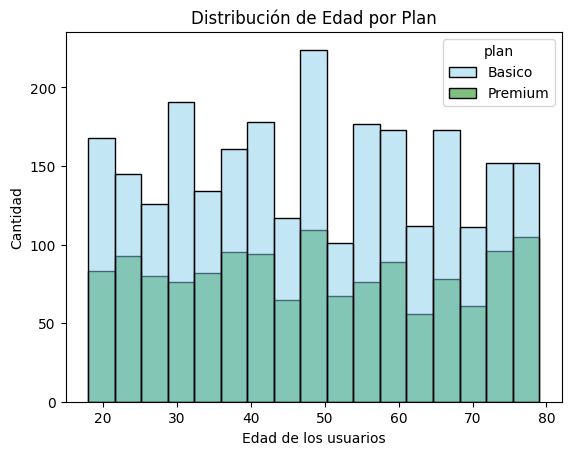

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad')
plt.show()


💡Insights: 
- Distribución ...

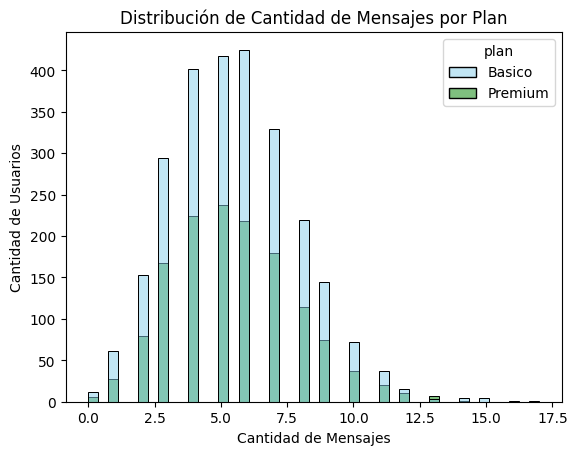

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x=("cant_mensajes", "sum"), hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- ....

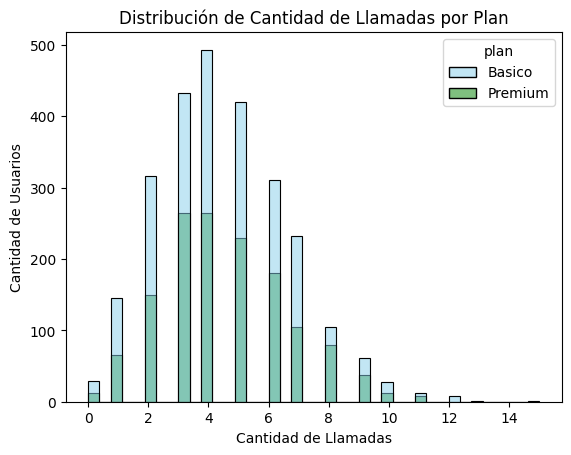

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x=('cant_llamadas', 'sum'), hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución ...

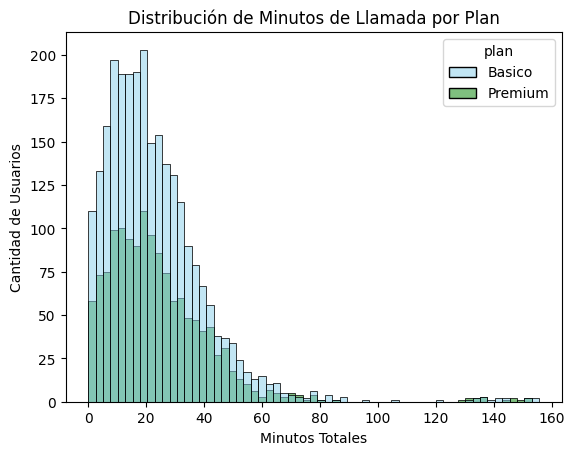

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x=('cant_minutos_llamada',"sum"), hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos Totales')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

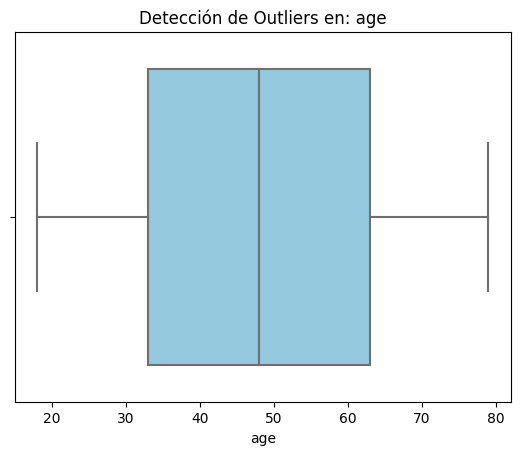

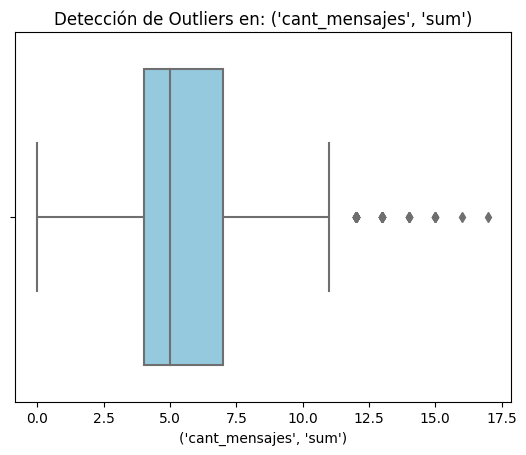

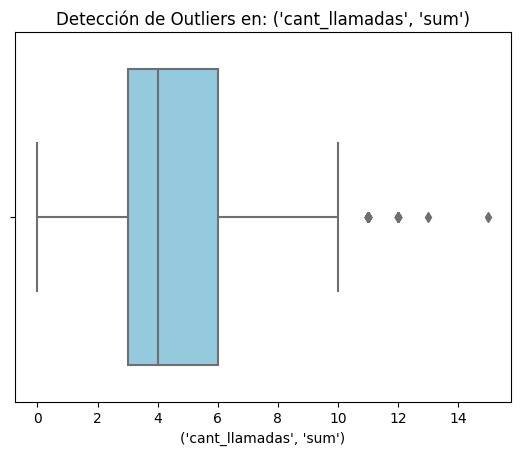

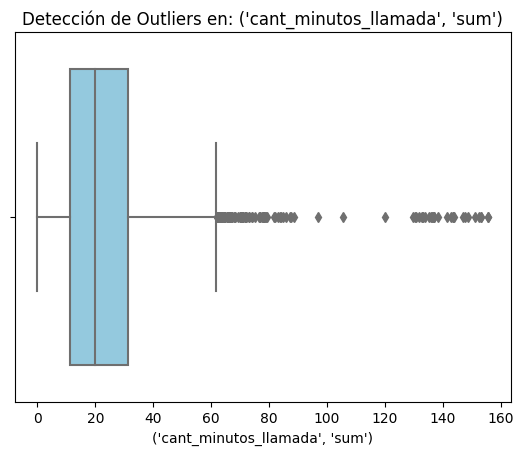

In [34]:
# Visualizando usando BoxPlot 


columnas_numericas = ['age', ('cant_mensajes',"sum"), ('cant_llamadas',"sum"), ('cant_minutos_llamada',"sum")]

 
for col in columnas_numericas:
     
    sns.boxplot(x=user_profile[col], color='skyblue')
    
     
    plt.title(f'Detección de Outliers en: {col}')
    plt.xlabel(col)
    
     
    plt.show()

💡Insights: 
- Age: sin outliers
- cant_mensajes:con outliers
- cant_llamadas: con outliers
- cant_minutos_llamada: con outliers

In [35]:
# Calcular límites con el método IQR
columnas_a_revisar = [
    ('cant_mensajes', "sum"), 
    ('cant_llamadas', "sum"), 
    ('cant_minutos_llamada', "sum")
]

 
for col in columnas_a_revisar:
    
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    
    print(f"--- Límites para la columna {col} ---")
    print("Límite inferior:", limite_inferior)
    print("Límite superior:", limite_superior)
    print() # Salto de línea para separar cada columna



--- Límites para la columna ('cant_mensajes', 'sum') ---
Límite inferior: -0.5
Límite superior: 11.5

--- Límites para la columna ('cant_llamadas', 'sum') ---
Límite inferior: -1.5
Límite superior: 10.5

--- Límites para la columna ('cant_minutos_llamada', 'sum') ---
Límite inferior: -19.322500000000005
Límite superior: 61.8575



In [36]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
columnas_limites = [
    ('cant_mensajes', "sum"), 
    ('cant_llamadas', "sum"), 
    ('cant_minutos_llamada', "sum")
]

# Generamos el resumen estadístico para ver el valor 'max'
user_profile[columnas_limites].describe()


,"(cant_mensajes, sum)","(cant_llamadas, sum)","(cant_minutos_llamada, sum)"
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
respuesta a los 3 , los 3 tienen maximos de mas del doble por lo que siguiendo la teoria tendria que windorizar pero siguiendo la logica es coherente que haya personas que se llamen muchisimo o se manden muchisimos mensajes como puede ser una familia en crisis o una pareja en fase de luna de miel y me parece mejor mantenerlos

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
# 1. Creamos la función con if / elif / else
def clasificar_uso(row):
    # Extraemos los valores de la fila actual
    llamadas = row[('cant_llamadas',"sum")]
    mensajes = row[('cant_mensajes',"sum")]
    
    # Evaluamos las condiciones
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# 2. Aplicamos la función al DataFrame para crear la nueva columna
# axis=1 significa que va a evaluar fila por fila (usuario por usuario)
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

# 3. Verificamos el resultado
print(user_profile['grupo_uso'].value_counts())

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,"(cant_minutos_llamada, sum)","(cant_minutos_llamada, mean)","(cant_minutos_llamada, count)","(cant_mensajes, sum)","(cant_llamadas, sum)",grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,23.70,7.900000,3.0,7.0,3.0,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,33.18,3.318000,10.0,5.0,10.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,10.74,5.370000,2.0,5.0,2.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,8.99,2.996667,3.0,11.0,3.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,8.01,2.670000,3.0,4.0,3.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
 
def clasificar_edad(row):
    edad = row['age']  
    
     
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

 
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

 
print(user_profile['grupo_edad'].value_counts())

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,"(cant_minutos_llamada, sum)","(cant_minutos_llamada, mean)","(cant_minutos_llamada, count)","(cant_mensajes, sum)","(cant_llamadas, sum)",grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,23.70,7.900000,3.0,7.0,3.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,33.18,3.318000,10.0,5.0,10.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,10.74,5.370000,2.0,5.0,2.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,8.99,2.996667,3.0,11.0,3.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,8.01,2.670000,3.0,4.0,3.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

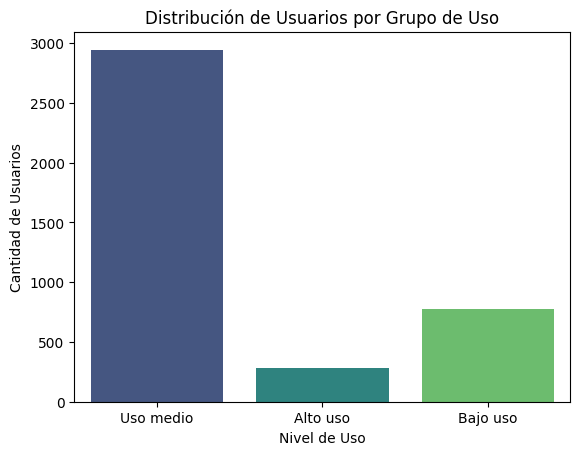

In [41]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Nivel de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


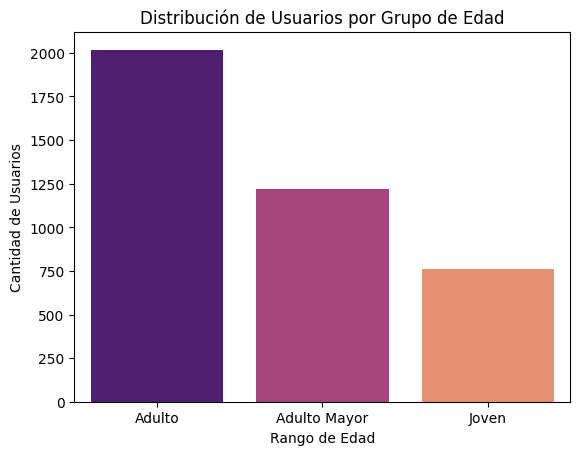

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='magma')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Valores Nulos (Faltantes): El dataset de usage tenía un problema grave, con un 55.19% de nulos en la duración y un 44.74% en la longitud (length). En users, la columna churn_date tenía un 88.35% de nulos, lo cual es normal e indica que la mayoría de los clientes aún están activos.
Valores Inválidos (Sentinels): Encontramos edades falsas de -999 que distorsionaban el promedio (bajándolo a 33 años cuando el real era 48). En la ciudad (city), había 96 registros con el símbolo '?' y 469 nulos reales (11.7%). Finalmente, detectamos 40 registros con fechas de registro en el futuro (año 2026).


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- Adultos (30 a 59 años): Son el segmento dominante absoluto con 2,018 usuarios (más de la mitad de la base de clientes).
Adultos Mayores (60+ años): Es el segundo grupo más grande con 1,222 usuarios.
Jóvenes (< 30 años): Es el segmento más pequeño con solo 760 usuarios.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Uso Medio: Es el comportamiento típico de la gran mayoría de la base, agrupando a 2,943 usuarios.
Bajo Uso: Representa a 778 usuarios que casi no utilizan sus líneas.
Alto Uso: Es un nicho muy pequeño pero activo de solo 279 usuarios.
El segmento de "Adultos" con "Uso Medio" y "Alto Uso" es el motor financiero de la empresa. Aunque los de "Alto Uso" son pocos (279), son los "Heavy Users" que más consumen la red y, probablemente, los que más pagan por excedentes o planes Premium.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Se detectaron outliers (valores atípicos) por encima del límite superior en las 3 variables de consumo: Mensajes (máx 17 vs límite 11.5), Llamadas (máx 15 vs límite 10.5) y Minutos (máx 155.69 vs límite 61.85).
Implicación para el negocio: Como decidimos mantenerlos, sabemos que estos no son errores, sino clientes reales con necesidades extremas de comunicación. Si no se les cuida, podrían frustrarse por cobros extra y hacer churn (cancelar el servicio) hacia la competencia.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Proteger a los Heavy Users: Crear un "Add-on" (paquete extra) de llamadas o mensajes ilimitados dirigido específicamente a esos 279 clientes de "Alto uso" (los outliers) para fidelizarlos y evitar que se vayan a la competencia.
Estrategia para Jóvenes: Dado que los jóvenes (menores de 30) son el segmento más pequeño (solo 760), ConnectaTel debería diseñar un plan atractivo para ellos, quizás enfocado 100% en Datos (GB) y redes sociales, restando importancia a los mensajes de texto tradicionales.
Mejorar la captura de datos: Recomendar al equipo de TI o Ventas que hagan obligatorio el campo de "Ciudad" al registrar un cliente y que validen que el sistema no permita ingresar fechas futuras (como 2026) ni edades negativas (-999) para evitar este trabajo de limpieza en el futuro.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ Problemas detectados en los datos
Valores Nulos (Faltantes): El dataset de usage tenía un problema grave, con un 55.19% de nulos en la duración y un 44.74% en la longitud (length). En users, la columna churn_date tenía un 88.35% de nulos, lo cual es normal e indica que la mayoría de los clientes aún están activos.
Valores Inválidos (Sentinels): Encontramos edades falsas de -999 que distorsionaban el promedio (bajándolo a 33 años cuando el real era 48). En la ciudad (city), había 96 registros con el símbolo '?' y 469 nulos reales (11.7%). Finalmente, detectamos 40 registros con fechas de registro en el futuro (año 2026).
🔍 Segmentos por Edad
Adultos (30 a 59 años): Son el segmento dominante absoluto con 2,018 usuarios (más de la mitad de la base de clientes).
Adultos Mayores (60+ años): Es el segundo grupo más grande con 1,222 usuarios.
Jóvenes (< 30 años): Es el segmento más pequeño con solo 760 usuarios.
📊 Segmentos por Nivel de Uso
Uso Medio: Es el comportamiento típico de la gran mayoría de la base, agrupando a 2,943 usuarios.
Bajo Uso: Representa a 778 usuarios que casi no utilizan sus líneas.
Alto Uso: Es un nicho muy pequeño pero activo de solo 279 usuarios.
💎 Segmentos más valiosos para ConnectaTel
El segmento de "Adultos" con "Uso Medio" y "Alto Uso" es el motor financiero de la empresa. Aunque los de "Alto Uso" son pocos (279), son los "Heavy Users" que más consumen la red y, probablemente, los que más pagan por excedentes o planes Premium.
📈 Patrones de uso extremo (Outliers) e Implicaciones
Se detectaron outliers (valores atípicos) por encima del límite superior en las 3 variables de consumo: Mensajes (máx 17 vs límite 11.5), Llamadas (máx 15 vs límite 10.5) y Minutos (máx 155.69 vs límite 61.85).
Implicación para el negocio: Como decidimos mantenerlos, sabemos que estos no son errores, sino clientes reales con necesidades extremas de comunicación. Si no se les cuida, podrían frustrarse por cobros extra y hacer churn (cancelar el servicio) hacia la competencia.
💡 Recomendaciones
Proteger a los Heavy Users: Crear un "Add-on" (paquete extra) de llamadas o mensajes ilimitados dirigido específicamente a esos 279 clientes de "Alto uso" (los outliers) para fidelizarlos y evitar que se vayan a la competencia.
Estrategia para Jóvenes: Dado que los jóvenes (menores de 30) son el segmento más pequeño (solo 760), ConnectaTel debería diseñar un plan atractivo para ellos, quizás enfocado 100% en Datos (GB) y redes sociales, restando importancia a los mensajes de texto tradicionales.
Mejorar la captura de datos: Recomendar al equipo de TI o Ventas que hagan obligatorio el campo de "Ciudad" al registrar un cliente y que validen que el sistema no permita ingresar fechas futuras (como 2026) ni edades negativas (-999) para evitar este trabajo de limpieza en el futuro.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`